# Guided Numeric Exploration — AI Model Arena Rankings (2023–2026)
_Human-preference Elo snapshots across text, vision, webdev, and search arenas_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [riyagarg0314/ai-model-arena-rankings-2023-2026](https://www.kaggle.com/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Snapshot Mix](#Univariate)** <br>
**4. [Frontier Elo Over Time](#Frontier)** <br>
**5. [Organizations and Licenses](#Orgs)** <br>
**6. [Votes, Uncertainty, Cross-Subset](#Votes)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Historical Chatbot Arena / LMArena Elo rankings (~97k rows) from May 2023 through July 2026. Each row is a model on a published leaderboard snapshot for one `subset` arena (`text`, `text_style_control`, `vision`, `webdev`, `search`). `category` is always `overall`.

Ratings are Bradley-Terry / Elo-style human preference scores with optional CI bounds and vote counts. Organization is ~3% null — left as missing, not imputed. The file ships with a double extension (`ai_model_arena_rankings.csv.csv`).


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "riyagarg0314/ai-model-arena-rankings-2023-2026"
EXPECTED_COLS = [
    "model_name", "organization", "license", "rating", "rating_lower", "rating_upper",
    "variance", "vote_count", "rank", "category", "leaderboard_publish_date", "subset",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    patterns = ["ai_model_arena_rankings.csv.csv", "ai_model_arena_rankings.csv", "*arena*rankings*.csv*"]
    if kaggle_root.exists():
        for pat in patterns:
            hits = list(kaggle_root.rglob(pat))
            if hits:
                return hits[0]
        raise AssertionError("arena rankings csv not under /kaggle/input")
    for name in ["ai_model_arena_rankings.csv.csv", "ai_model_arena_rankings.csv"]:
        local = Path("data") / name
        if local.exists():
            return local
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob("*arena*rankings*.csv*"))
    assert hits, f"arena rankings csv not under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 97377, f"expected 97377 rows, got {len(df)}"
assert (df["category"] == "overall").all()

df["leaderboard_publish_date"] = pd.to_datetime(df["leaderboard_publish_date"], errors="coerce")
assert df["leaderboard_publish_date"].notna().all()
df["ci_width"] = df["rating_upper"] - df["rating_lower"]

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Date range:", df["leaderboard_publish_date"].min().date(), "→", df["leaderboard_publish_date"].max().date())
print("Snapshots:", df["leaderboard_publish_date"].nunique())
print("Models:", df["model_name"].nunique())
print("subset:", df["subset"].value_counts().to_dict())
print("organization null share: {:.1%}".format(df["organization"].isna().mean()))

text = df[df["subset"] == "text"].copy()
assert len(text) > 40_000


  0%|          | 0.00/4.76M [00:00<?, ?B/s]

 21%|██        | 1.00M/4.76M [00:00<00:02, 1.48MB/s]

 42%|████▏     | 2.00M/4.76M [00:01<00:01, 1.74MB/s]

 63%|██████▎   | 3.00M/4.76M [00:01<00:00, 1.99MB/s]

 84%|████████▍ | 4.00M/4.76M [00:02<00:00, 2.05MB/s]

100%|██████████| 4.76M/4.76M [00:02<00:00, 2.14MB/s]

100%|██████████| 4.76M/4.76M [00:02<00:00, 2.00MB/s]

Extracting files...


CSV: /Users/nicapotato/.cache/kagglehub/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026/versions/1/ai_model_arena_rankings.csv.csv
Missing Values: 5143
Dataframe Dimension: 97377 Rows, 13 Columns
Date range: 2023-05-08 → 2026-07-10
Snapshots: 247
Models: 461
subset: {'text': 45123, 'text_style_control': 40141, 'vision': 8229, 'webdev': 3292, 'search': 592}
organization null share: 3.6%


**Code Explanation and Reasoning:** <br>
Filename resolution tolerates the double `.csv.csv` quirk. `category` is asserted to be entirely `overall`. Dates are parsed; CI width is derived only where bounds exist. The `text` subset is the primary panel for frontier plots.


In [3]:
df.sample(5, random_state=7)


,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset,ci_width
6759,chatglm3-6b,Tsinghua,Apache-2.0,955.181934,945.264869,964.539291,25.355662,4765.0,136.0,overall,2024-12-15,text,19.274423
35385,claude-3-5-sonnet-20240620,anthropic,Proprietary,1280.642152,1277.134395,1284.149909,3.203044,82419.0,194.0,overall,2026-04-10,text,7.015515
15737,llama-2-7b-chat,meta,Llama 2 Community,1061.235834,1054.471608,1068.000060,11.910777,14532.0,192.0,overall,2025-07-25,text,13.528453
33437,phi-3-medium-4k-instruct,microsoft,MIT,1137.523608,1132.306974,1142.740242,7.084098,25055.0,264.0,overall,2026-03-20,text,10.433268
81922,solar-10.7b-instruct-v1.0,NaN,CC-BY-NC-4.0,1151.118866,1137.933109,1164.304623,45.259935,4155.0,318.0,overall,2026-05-19,text_style_control,26.371513


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))
df[["rating", "vote_count", "rank", "ci_width"]].describe().T.round(2)


,Column,Unique,Null
1,organization,66,3477
4,rating_lower,93752,307
5,rating_upper,93752,307
6,variance,93749,307
7,vote_count,19264,307
12,ci_width,93749,307
2,license,40,131
0,model_name,461,0
3,rating,93794,0
8,rank,374,0


,count,mean,std,min,25%,50%,75%,max
rating,97377.0,1232.58,145.45,789.0,1125.96,1240.19,1348.77,1664.99
vote_count,97070.0,23586.33,27389.38,54.0,5243.00,12857.00,32191.00,202735.00
rank,97377.0,119.16,89.94,1.0,43.00,99.00,180.00,374.00
ci_width,97070.0,14.14,7.35,0.0,8.65,12.51,18.26,104.54


**Interpretation** <br>
This is a panel: models × snapshots × arena subsets. Nulls concentrate in CI/vote fields on early snapshots and in organization for some entries.


# **3. Univariate Snapshot Mix:** <a id="Univariate"></a>


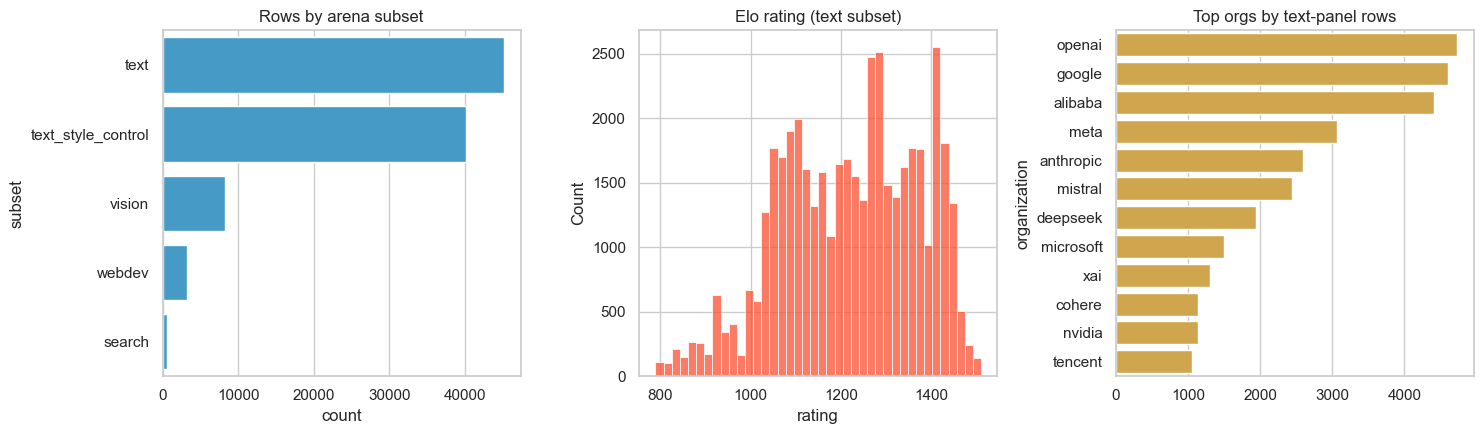

In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, y="subset", order=df["subset"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Rows by arena subset")
sns.histplot(text["rating"], bins=40, ax=ax[1], color="#fc4f30")
ax[1].set_title("Elo rating (text subset)")
top_org = text["organization"].value_counts().head(12)
sns.barplot(x=top_org.values, y=top_org.index, ax=ax[2], color="#e5ae38")
ax[2].set_title("Top orgs by text-panel rows")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Text and style-control dominate row counts because they have longer histories. Org bar counts are appearance-weighted (more snapshots × more models), not unique-model counts.


# **4. Frontier Elo Over Time:** <a id="Frontier"></a>


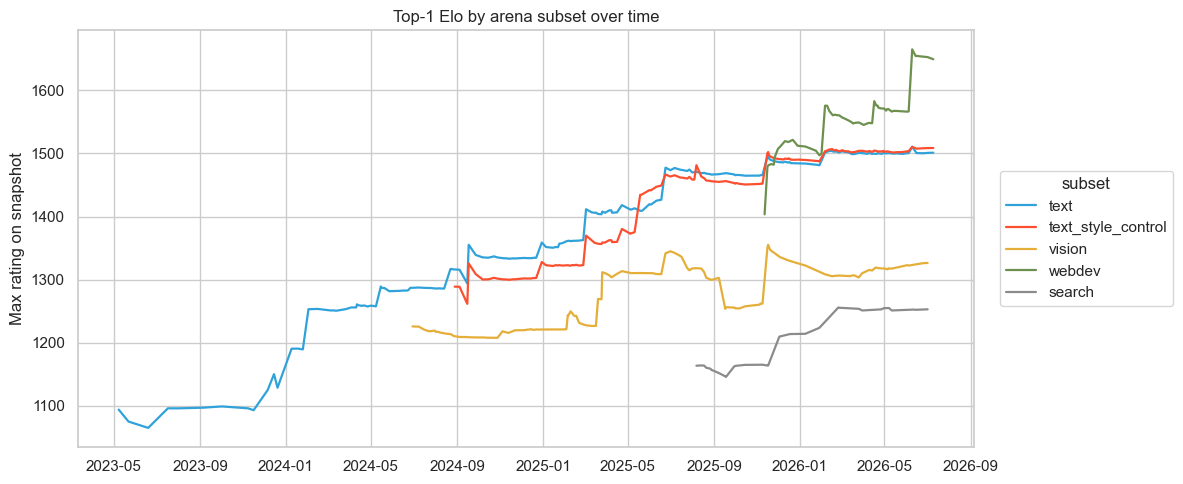

,leaderboard_publish_date,model_name,organization,rating,rank
211,2026-05-14,claude-opus-4-6-thinking,anthropic,1499.640926,1.0
212,2026-05-18,claude-opus-4-6-thinking,anthropic,1499.870938,1.0
213,2026-05-19,claude-opus-4-6-thinking,anthropic,1500.036179,1.0
214,2026-05-27,claude-opus-4-6-thinking,anthropic,1499.317340,1.0
215,2026-06-03,claude-opus-4-6-thinking,anthropic,1500.393573,1.0
216,2026-06-04,claude-opus-4-6-thinking,anthropic,1500.346426,1.0
217,2026-06-05,claude-opus-4-6-thinking,anthropic,1500.547773,1.0
218,2026-06-10,claude-opus-4-6-thinking,anthropic,1510.631267,1.0
219,2026-06-16,claude-opus-4-6-thinking,anthropic,1500.668125,1.0
220,2026-06-25,claude-opus-4-6-thinking,anthropic,1500.252515,1.0


Unique text #1 models: 22
Top #1 holders: {'claude-opus-4-6-thinking': 40, 'gemini-2.5-pro': 27, 'gpt-4o-2024-05-13': 24, 'gemini-3-pro': 20, 'o1-preview': 18, 'o3-2025-04-16': 13, 'claude-opus-4-6': 13, 'deepseek-r1': 11}


In [6]:
def frontier_series(frame: pd.DataFrame, top_k: int = 1) -> pd.DataFrame:
    g = (
        frame.groupby("leaderboard_publish_date", as_index=False)
        .apply(lambda d: d.nlargest(top_k, "rating")[["leaderboard_publish_date", "rating", "model_name", "organization"]],
               include_groups=False)
    )
    # groupby.apply can nest; normalize
    if isinstance(g, pd.Series):
        g = g.reset_index(drop=True)
    return g.reset_index(drop=True)


# Simpler: top-1 and median rating per date × subset
frontier = (
    df.groupby(["subset", "leaderboard_publish_date"])["rating"]
    .agg(top1="max", median="median", n="count")
    .reset_index()
)

f, ax = plt.subplots(figsize=(12, 5))
for subset, color in zip(
    ["text", "text_style_control", "vision", "webdev", "search"],
    ["#30a2da", "#fc4f30", "#e5ae38", "#6d904f", "#8b8b8b"],
):
    s = frontier[frontier["subset"] == subset].sort_values("leaderboard_publish_date")
    if s.empty:
        continue
    ax.plot(s["leaderboard_publish_date"], s["top1"], label=subset, color=color, lw=1.6)
ax.set_title("Top-1 Elo by arena subset over time")
ax.set_ylabel("Max rating on snapshot")
ax.legend(title="subset", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Who holds #1 on text over time
text_sorted = text.sort_values(["leaderboard_publish_date", "rank"])
leaders = text_sorted.groupby("leaderboard_publish_date", as_index=False).first()[
    ["leaderboard_publish_date", "model_name", "organization", "rating", "rank"]
]
assert (leaders["rank"] == 1).all() or leaders["rank"].isna().any()
display(leaders.tail(12))
print("Unique text #1 models:", leaders["model_name"].nunique())
print("Top #1 holders:", leaders["model_name"].value_counts().head(8).to_dict())


**How to Interpret:** <br>
Rising top-1 Elo traces the preference frontier. Subsets are not directly comparable as absolute Elo scales may differ — compare shapes and leadership churn, not raw cross-arena points.


# **5. Organizations and Licenses:** <a id="Orgs"></a>


Latest text snapshot: 2026-07-10 n= 374


,n,mean_rating,best
organization,,,
anthropic,28,1386.6,1501.2
google,36,1300.6,1480.1
meta,19,1187.9,1477.9
alibaba,40,1325.1,1475.4
openai,42,1351.9,1468.6
zai,14,1386.7,1467.4
baidu,4,1446.1,1467.3
xiaomi,6,1425.7,1462.4
moonshot,6,1414.2,1455.6


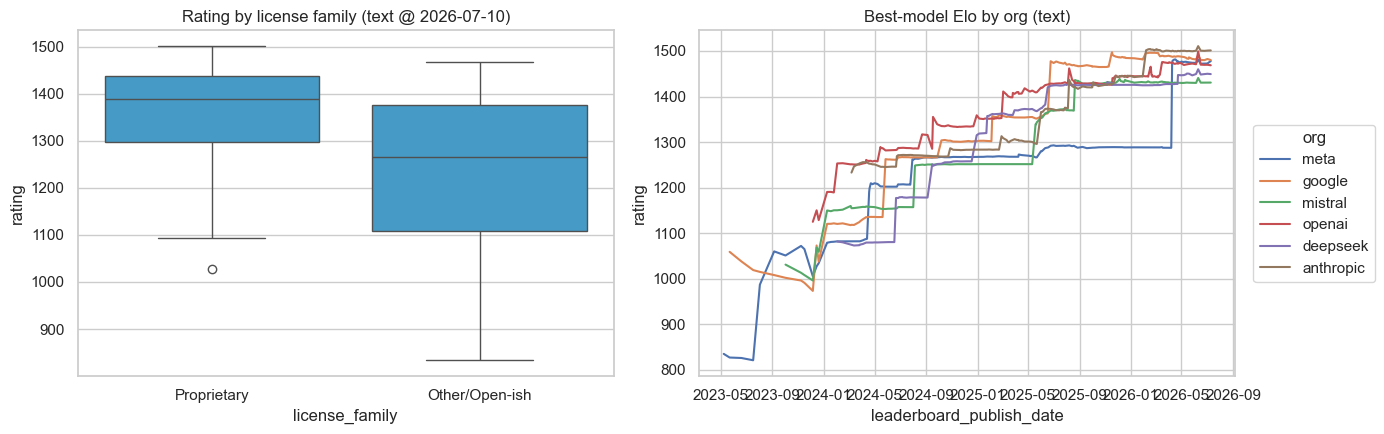

In [7]:
# Latest text snapshot org mean rating among ranked models
latest_date = text["leaderboard_publish_date"].max()
latest = text[text["leaderboard_publish_date"] == latest_date].copy()
print("Latest text snapshot:", latest_date.date(), "n=", len(latest))

org_stats = (
    latest.dropna(subset=["organization"])
    .groupby("organization")
    .agg(n=("model_name", "count"), mean_rating=("rating", "mean"), best=("rating", "max"))
    .sort_values("best", ascending=False)
    .head(15)
)
display(org_stats.round(1))

# Proprietary vs open-ish on latest text board
latest["license_family"] = np.where(
    latest["license"].astype(str).str.contains("Proprietary", case=False, na=False),
    "Proprietary",
    "Other/Open-ish",
)
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=latest, x="license_family", y="rating", ax=ax[0], color="#30a2da")
ax[0].set_title(f"Rating by license family (text @ {latest_date.date()})")
# Org trajectory: mean rating of org's best model over time (top orgs)
focus_orgs = ["openai", "google", "anthropic", "meta", "mistral", "deepseek"]
best_by_org = (
    text.dropna(subset=["organization"])
    .assign(organization=lambda d: d["organization"].str.lower())
    .query("organization in @focus_orgs")
    .groupby(["leaderboard_publish_date", "organization"])["rating"]
    .max()
    .reset_index()
)
sns.lineplot(
    data=best_by_org, x="leaderboard_publish_date", y="rating", hue="organization", ax=ax[1],
)
ax[1].set_title("Best-model Elo by org (text)")
ax[1].legend(title="org", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Latest-snapshot org tables show who fields competitive models *now*. Best-model trajectories show whether an org's frontier entry keeps pace — not the quality of their average release.


# **6. Votes, Uncertainty, Cross-Subset:** <a id="Votes"></a>


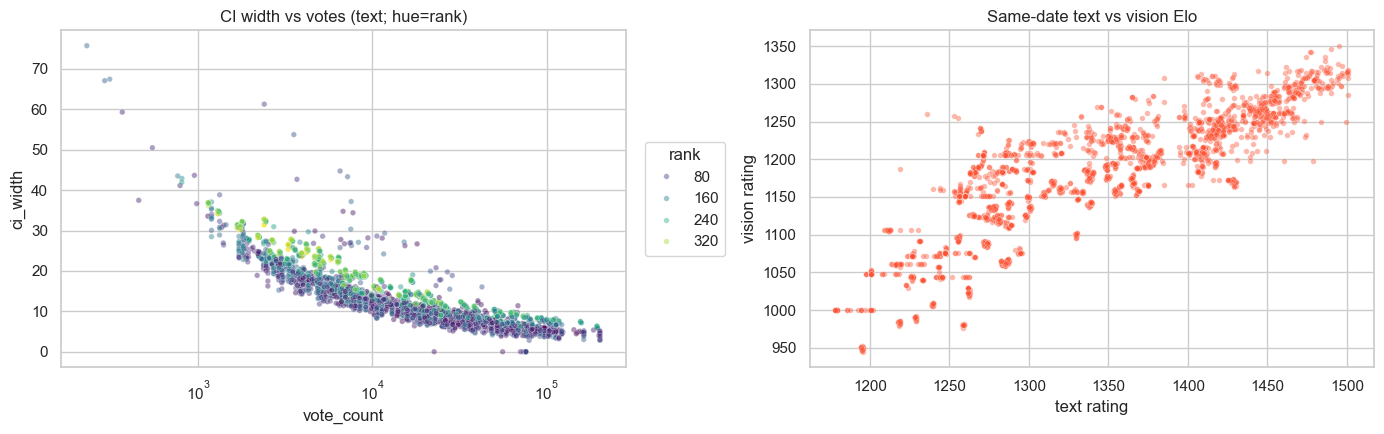

Pearson r(text, vision) same-date: 0.855
Paired model-date rows: 5299


In [8]:
voted = text.dropna(subset=["vote_count", "ci_width"])
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(
    data=voted.sample(min(5000, len(voted)), random_state=7),
    x="vote_count", y="ci_width", hue="rank", palette="viridis", ax=ax[0], alpha=0.45, s=16,
)
ax[0].set_xscale("log")
ax[0].set_title("CI width vs votes (text; hue=rank)")
ax[0].legend(title="rank", bbox_to_anchor=(1.02, 0.5), loc="center left")

# Cross-subset: models present in text and vision on same date
vision = df[df["subset"] == "vision"][["model_name", "leaderboard_publish_date", "rating"]].rename(
    columns={"rating": "rating_vision"}
)
both = text[["model_name", "leaderboard_publish_date", "rating"]].merge(
    vision, on=["model_name", "leaderboard_publish_date"], how="inner"
)
assert len(both) > 0
sns.scatterplot(data=both.sample(min(3000, len(both)), random_state=7),
                x="rating", y="rating_vision", ax=ax[1], alpha=0.4, s=16, color="#fc4f30")
ax[1].set_xlabel("text rating")
ax[1].set_ylabel("vision rating")
ax[1].set_title("Same-date text vs vision Elo")
plt.tight_layout()
plt.show()
print("Pearson r(text, vision) same-date:", round(both["rating"].corr(both["rating_vision"]), 3))
print("Paired model-date rows:", len(both))


**How to Interpret:** <br>
Narrower CIs with more votes mean more stable rankings. Text–vision scatter asks whether chat strength transfers to multimodal preference on the same publish date.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A multi-year panel of Arena overall Elo snapshots across five subset arenas.

**Working takeaways:** <br>
- Track frontiers within a subset; avoid naive cross-subset Elo comparisons.
- Org trajectories use each org's best model per date.
- Leave organization / CI nulls alone — early boards are thinner.

**Open follow-ups:** <br>
- Survival of top-10 membership (churn heatmaps).
- Style-control vs raw text ranking deltas for the same model.
